# [Scintillation Detector](https://www.kaggle.com/competitions/scintillation-detector)

In [264]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import seaborn as sns

In [265]:
X = pd.read_csv('scintillation-detector/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,495,496,497,498,499,500,501,502,503,504
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,0.0
mean,1.009742e+11,869.160015,372.191661,500.0,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,...,14822.315686,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743,NaN
std,5.715472e+10,572.905756,470.391688,0.0,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,...,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307,NaN
min,2.890276e+06,0.000000,10.000000,500.0,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,...,14798.000000,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000,NaN
25%,5.156311e+10,373.000000,64.000000,500.0,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,NaN
50%,1.014553e+11,810.000000,172.000000,500.0,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,NaN
75%,1.502418e+11,1341.000000,483.000000,500.0,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,NaN
max,2.000107e+11,1998.000000,3370.000000,500.0,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,...,14835.000000,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000,NaN


In [266]:
# X_long = pd.melt(X, id_vars=[0], value_vars=list(range(4, 504)), var_name='Category', value_name='Value')
# sns.lineplot(data=X_long, x=0, y='Value', hue='Category');

In [267]:
slice_df = X.iloc[:, 4:504]
X[504] = slice_df.max(axis=1) - slice_df.min(axis=1)

In [268]:
X[505] = slice_df.sum(axis=1)

In [269]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,496,497,498,499,500,501,502,503,504,505
count,2.347900e+04,23479.000000,23479.000000,23479.0,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,2.347900e+04
mean,1.009742e+11,869.160015,372.191661,500.0,14822.972316,14822.958474,14822.970016,14822.989991,14823.003961,14822.978619,...,14822.272073,14822.171728,14822.257123,14822.317092,14822.279399,14822.278163,14822.287789,14822.283743,1842.849568,7.398342e+06
std,5.715472e+10,572.905756,470.391688,0.0,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,...,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307,2389.075855,1.610492e+04
min,2.890276e+06,0.000000,10.000000,500.0,14812.000000,14812.000000,14812.000000,14811.000000,14812.000000,14812.000000,...,14802.000000,14796.000000,14802.000000,14801.000000,14798.000000,14804.000000,14800.000000,14802.000000,113.000000,7.298399e+06
25%,5.156311e+10,373.000000,64.000000,500.0,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,14821.000000,...,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,14820.000000,316.000000,7.394148e+06
50%,1.014553e+11,810.000000,172.000000,500.0,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,...,14823.000000,14822.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,14823.000000,820.000000,7.405248e+06
75%,1.502418e+11,1341.000000,483.000000,500.0,14824.000000,14824.000000,14825.000000,14825.000000,14825.000000,14824.000000,...,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,14824.000000,2322.500000,7.409017e+06
max,2.000107e+11,1998.000000,3370.000000,500.0,14834.000000,14835.000000,14834.000000,14835.000000,14834.000000,14835.000000,...,14834.000000,14836.000000,14833.000000,14834.000000,14833.000000,14834.000000,14833.000000,14835.000000,14833.000000,7.411894e+06


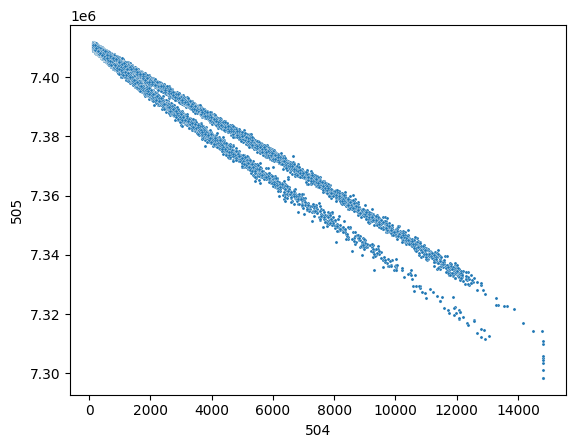

In [270]:
sns.scatterplot(data=X, x=504, y=505, s=5)
# sns.kdeplot(data=X, x=1, y=2, fill=True, alpha=0.3)
plt.show()

In [271]:
# fig, ax = plt.subplots()
# def animate(i):
#     ax.clear()
#     sns.lineplot(data=X.iloc[i][4:504], ax=ax)
#     ax.set_title(f'Row {i}, time: {X.iloc[i][0]}, par1: {X.iloc[i][1]}, 2: {X.iloc[i][2]}')

# anim = FuncAnimation(fig, animate, frames=range(10000, 10100), interval=200, repeat=True)
# anim.save('lineplot_animation.gif', writer='pillow', fps=1)

In [272]:
def scaling(X):
    from sklearn.preprocessing import MinMaxScaler, StandardScaler
    scaler = MinMaxScaler(X)
    return scaler.fit_transform(X)

def exeptions(X):
    from sklearn.ensemble import IsolationForest
    iso = IsolationForest(n_estimators=200, contamination="auto", max_samples='auto', random_state=42, n_jobs=-1)
    return iso.fit_predict(X) == 1

def decomposition(X, n_dim):
    from sklearn.decomposition import PCA
    pca = PCA(n_components=n_dim, random_state=42)
    return pca.fit_transform(X)

def clasterisation(X):
    from sklearn.cluster import KMeans, SpectralClustering
    kmeans = SpectralClustering(n_clusters=2, random_state=42)
    return kmeans.fit_predict(X)

In [273]:
def pipeline(X):
    X = X.copy()
    X = X.drop(columns=[0, 1, 2, 3, 504])
#    X = X.drop(columns=[3, 504])
#    X[2] = np.log2(X[2])

    labels = np.full(shape=X.shape[0], fill_value=-1, dtype=int)
    is_normal = exeptions(X)
    X_normal = X[is_normal]
#    X_normal = decomposition(X_normal, 50)

    labels[is_normal] = clasterisation(X_normal)

    return labels

In [274]:
y = pd.DataFrame()
y[0] = X[504]
y[1] = X[505]
X_in = y.to_numpy()

<Axes: xlabel='0', ylabel='1'>

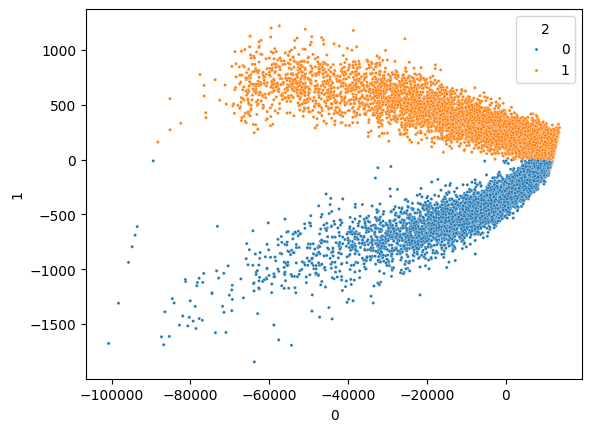

In [275]:
from sklearn.decomposition import PCA

y = pd.DataFrame(PCA(n_components=2, random_state=42).fit_transform(X_in))
y[2] = y[1] > 0
y[2] = y[2].astype(int)
sns.scatterplot(data=y, x=0, y=1, hue=2, s=5)


In [276]:
pred = pd.Series(y[2], name='cluster').astype(int).reset_index()
pred.to_csv('scintillation-detector/result.csv', index=False)

In [277]:
!kaggle competitions submit -c scintillation-detector -f ./scintillation-detector/result.csv -m "Message"

User cancelled operation
^C
